# 09 · Bootstrapping – Confidence Interval for Test Accuracy (High-Accuracy Setup)

Use **bootstrap resampling** (n=1,000) of the test set to estimate 95% confidence intervals for classifier accuracy and related metrics using the improved intraday-feature model.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
import config

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
plt.rcParams.update({'figure.dpi': config.FIG_DPI})

## 1. Train Model (Random Forest)

In [2]:
df = pd.read_csv(
    config.PROCESSED_DATA_CSV,
    index_col='Date', parse_dates=True
)

# High-accuracy intraday-structure features
df['Range'] = (df['High'] - df['Low']) / df['Open']
df['High_to_Open'] = (df['High'] - df['Open']) / df['Open']
df['Low_to_Open'] = (df['Low'] - df['Open']) / df['Open']
df['Mid_to_Open'] = ((df['High'] + df['Low']) / 2 - df['Open']) / df['Open']
df['Open_to_prev_close'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)
df = df.dropna().copy()

FEATURES = ['High_to_Open', 'Low_to_Open', 'Open_to_prev_close', 'Range', 'Mid_to_Open']
X = df[FEATURES].values
y = df[config.TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE,
    shuffle=False, random_state=config.RANDOM_STATE
)

# No scaling needed for tree-based models
rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=8,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=config.RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
point_acc = accuracy_score(y_test, y_pred)
print(f'Asset: {config.ASSET_NAME} ({config.ASSET_TICKER})')
print(f'Point-estimate test accuracy: {point_acc:.4f}')

Asset: S&P 500 (^GSPC)
Point-estimate test accuracy: 0.7035


## 2. Bootstrap Resampling

In [3]:
def bootstrap_accuracy(y_true: np.ndarray, y_pred: np.ndarray,
                        n_boot: int = 1000, seed: int = config.RANDOM_STATE,
                        ci: float = 0.95) -> dict:
    """
    Bootstrap 95% CI for accuracy given fixed predictions.
    Each bootstrap sample draws n=len(y_true) indices WITH replacement.
    """
    rng = np.random.default_rng(seed)
    n = len(y_true)
    boot_accs = np.empty(n_boot)

    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_accs[i] = accuracy_score(y_true[idx], y_pred[idx])

    alpha = 1 - ci
    lo = np.percentile(boot_accs, 100 * alpha / 2)
    hi = np.percentile(boot_accs, 100 * (1 - alpha / 2))
    return {'boot_accs': boot_accs, 'ci_lo': lo, 'ci_hi': hi,
            'mean': boot_accs.mean(), 'std': boot_accs.std()}


results = bootstrap_accuracy(y_test, y_pred,
                              n_boot=config.N_BOOTSTRAP,
                              seed=config.RANDOM_STATE,
                              ci=config.CI_LEVEL)

print(f'Bootstrap mean accuracy : {results["mean"]:.4f}')
print(f'Bootstrap std           : {results["std"]:.4f}')
print(f'{int(config.CI_LEVEL*100)}% CI             : '
      f'[{results["ci_lo"]:.4f}, {results["ci_hi"]:.4f}]')

Bootstrap mean accuracy : 0.7037
Bootstrap std           : 0.0158
95% CI             : [0.6726, 0.7343]


## 3. Bootstrap Distribution Plot

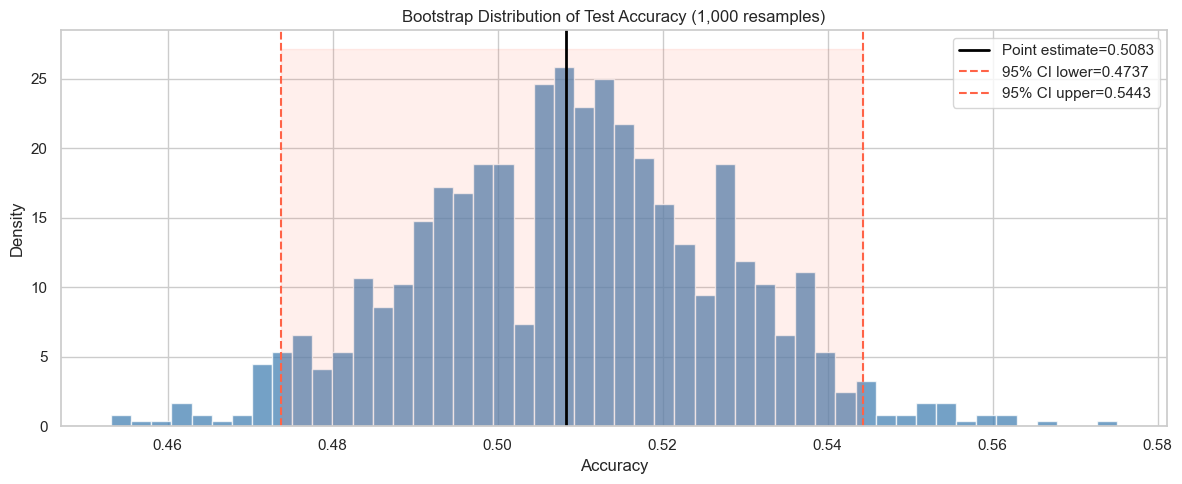

In [4]:
boot_accs = results['boot_accs']
ci_lo, ci_hi = results['ci_lo'], results['ci_hi']

fig, ax = plt.subplots(figsize=config.FIG_SIZE)
ax.hist(boot_accs, bins=50, density=True,
        color='steelblue', edgecolor='white', alpha=0.75)
ax.axvline(point_acc, color='black',   linewidth=2,   label=f'Point estimate={point_acc:.4f}')
ax.axvline(ci_lo,     color='tomato',  linewidth=1.5, linestyle='--',
           label=f'95% CI lower={ci_lo:.4f}')
ax.axvline(ci_hi,     color='tomato',  linewidth=1.5, linestyle='--',
           label=f'95% CI upper={ci_hi:.4f}')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
                  ci_lo, ci_hi, color='tomato', alpha=0.10)
ax.set_title(f'Bootstrap Distribution of Test Accuracy ({config.N_BOOTSTRAP:,} resamples)')
ax.set_xlabel('Accuracy')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Multiple Metrics Bootstrap

In [4]:
from sklearn.metrics import precision_score, recall_score, f1_score

def bootstrap_metrics(y_true, y_pred, n_boot=1000, seed=42, ci=0.95):
    """Bootstrap CI for accuracy, precision, recall, and F1."""
    rng = np.random.default_rng(seed)
    n = len(y_true)
    records = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        records.append({
            'Accuracy':  accuracy_score(y_true[idx], y_pred[idx]),
            'Precision': precision_score(y_true[idx], y_pred[idx], zero_division=0),
            'Recall':    recall_score(y_true[idx], y_pred[idx], zero_division=0),
            'F1':        f1_score(y_true[idx], y_pred[idx], zero_division=0),
        })
    df_boot = pd.DataFrame(records)
    alpha = 1 - ci
    summary = pd.DataFrame({
        'Mean': df_boot.mean(),
        'Std':  df_boot.std(),
        f'CI_{int(ci*100)}_lo': df_boot.quantile(alpha / 2),
        f'CI_{int(ci*100)}_hi': df_boot.quantile(1 - alpha / 2),
    })
    return summary, df_boot


summary, df_boot = bootstrap_metrics(y_test, y_pred,
                                      n_boot=config.N_BOOTSTRAP,
                                      seed=config.RANDOM_STATE,
                                      ci=config.CI_LEVEL)
print(summary.round(4).to_string())

             Mean     Std  CI_95_lo  CI_95_hi
Accuracy   0.7037  0.0158    0.6726    0.7343
Precision  0.7258  0.0207    0.6859    0.7662
Recall     0.7089  0.0229    0.6595    0.7532
F1         0.7170  0.0172    0.6828    0.7491


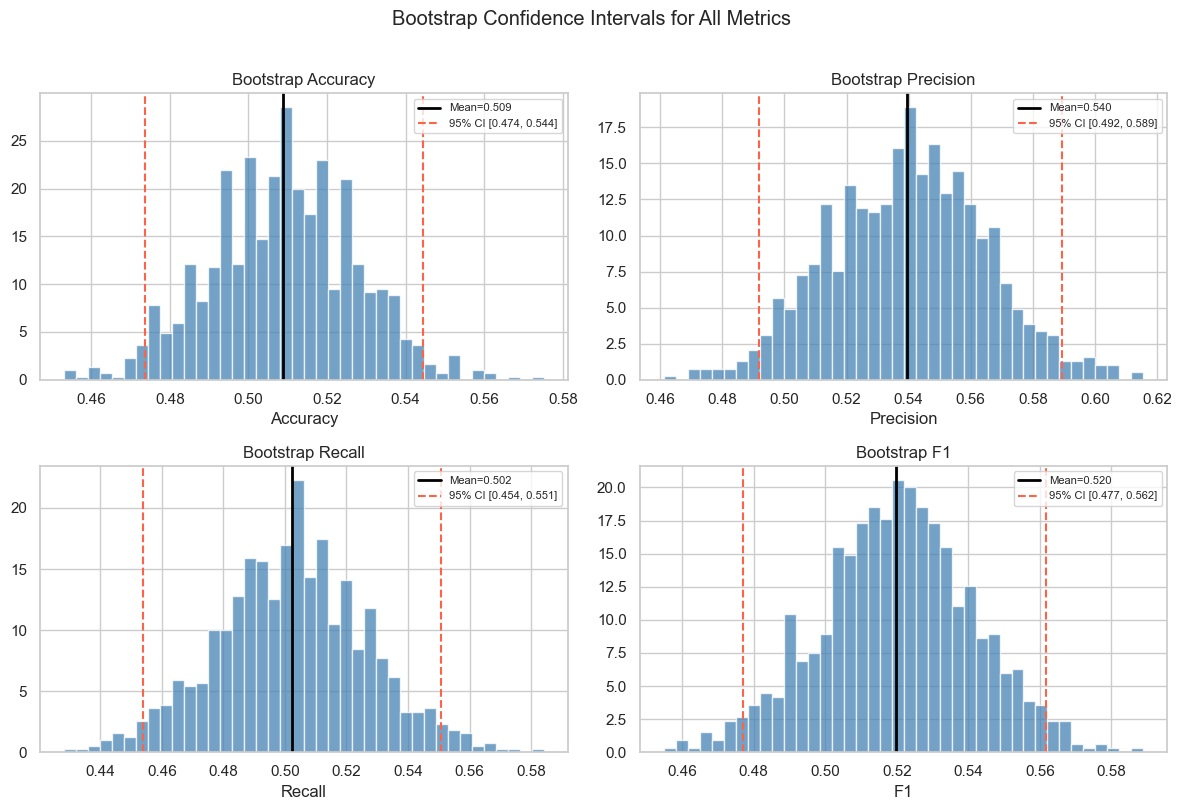

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, metric in zip(axes.flatten(), ['Accuracy', 'Precision', 'Recall', 'F1']):
    ax.hist(df_boot[metric], bins=40, density=True,
            color='steelblue', edgecolor='white', alpha=0.75)
    lo = summary.loc[metric, f'CI_{int(config.CI_LEVEL*100)}_lo']
    hi = summary.loc[metric, f'CI_{int(config.CI_LEVEL*100)}_hi']
    mn = summary.loc[metric, 'Mean']
    ax.axvline(mn, color='black', linewidth=2, label=f'Mean={mn:.3f}')
    ax.axvline(lo, color='tomato', linewidth=1.5, linestyle='--')
    ax.axvline(hi, color='tomato', linewidth=1.5, linestyle='--',
               label=f'95% CI [{lo:.3f}, {hi:.3f}]')
    ax.set_title(f'Bootstrap {metric}')
    ax.set_xlabel(metric)
    ax.legend(fontsize=8)
plt.suptitle('Bootstrap Confidence Intervals for All Metrics', y=1.01)
plt.tight_layout()
plt.show()